# Observation-threshold ablation data

Load all available observation-threshold-ablation JSONL results into one tidy DataFrame. This notebook intentionally performs no analysis or visualization.

The threshold calibration and selected-regime manifests are loaded separately so later analysis can report observed events/bin and retained-event fraction instead of relying on literal threshold values.

In [13]:
from __future__ import annotations

import json
import re
from pathlib import Path

import pandas as pd

REPO_ROOT = Path.cwd() if (Path.cwd() / 'derived').is_dir() else Path.cwd().parent
RESULTS_DIR = REPO_ROOT / 'derived' / 'results' / 'observation_threshold_ablation'
FILENAME_PATTERN = re.compile(
    r'^threshold_(?P<regime>dense|medium|sparse|very_sparse)_'
    r'(?P<dynamic>diffusion|wave|coupled_oscillator)_'
    r'(?P<topology>ring|grid|torus|doorway|swisscheese)_'
    r'models(?P<models>\d+)_epochs(?P<epochs>\d+)_nodes(?P<num_nodes>\d+)_'
    r'episodes(?P<num_episodes>\d+)_bins(?P<num_bins>\d+)_events(?P<events_per_bin>\d+)_'
    r'dropint(?P<raindrop_interval>\d+)_tau(?P<event_threshold>[0-9p]+)_'
    r'trainroll(?P<rollout_train_steps>\d+)_rollhorizon(?P<rollout_horizon>\d+)_'
    r'seed(?P<seed>\d+)\.jsonl$'
)


In [14]:
def decode_numeric_tag(value: str) -> float:
    return float(value.replace('p', '.'))


def load_threshold_results(results_dir: Path) -> pd.DataFrame:
    paths = sorted(results_dir.glob('threshold_*.jsonl'))
    if not paths:
        raise FileNotFoundError(f'No observation-threshold JSONLs found in {results_dir}')

    records: list[dict] = []
    for path in paths:
        match = FILENAME_PATTERN.fullmatch(path.name)
        if match is None:
            raise ValueError(f'Unexpected observation-threshold filename: {path.name}')

        raw_metadata = match.groupdict()
        metadata = {
            key: (decode_numeric_tag(value) if key == 'event_threshold' else value)
            for key, value in raw_metadata.items()
        }
        metadata.update({
            key: int(value)
            for key, value in raw_metadata.items()
            if key not in {'regime', 'dynamic', 'topology', 'event_threshold'}
        })

        with path.open(encoding='utf-8') as handle:
            for line_number, line in enumerate(handle, start=1):
                row = json.loads(line)
                row['source_file'] = path.name
                row['source_line'] = line_number
                row.update(metadata)
                records.append(row)

    # Flatten scalar metric dictionaries one level while retaining detailed
    # rollout curves as object-valued columns.
    return pd.json_normalize(records, sep='.', max_level=1)


threshold_df = load_threshold_results(RESULTS_DIR)
threshold_calibration_df = pd.read_csv(RESULTS_DIR / 'threshold_calibration.csv')
threshold_regimes_df = pd.read_csv(RESULTS_DIR / 'threshold_regimes.csv')
threshold_df


,run,seed,epoch,source_file,source_line,regime,dynamic,topology,models,epochs,...,rollout_test.rollout_persistent_event_auroc,rollout_test.rollout_persistent_event_auprc,rollout_test.rollout_persistent_event_balanced_acc,rollout_test.rollout_persistent_event_false_positive_rate,rollout_test.rollout_persistent_event_pred_positive_rate,rollout_test.rollout_persistent_event_true_positive_rate,rollout_test.rollout_by_step,rollout_test.rollout_by_steps_since_external,rollout_test.rollout_persistent_by_step,rollout_test.rollout_persistent_by_steps_since_external
0,fnn,0,1,threshold_dense_coupled_oscillator_doorway_mod...,1,dense,coupled_oscillator,doorway,4,20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,fnn,0,2,threshold_dense_coupled_oscillator_doorway_mod...,2,dense,coupled_oscillator,doorway,4,20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,fnn,0,3,threshold_dense_coupled_oscillator_doorway_mod...,3,dense,coupled_oscillator,doorway,4,20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,fnn,0,4,threshold_dense_coupled_oscillator_doorway_mod...,4,dense,coupled_oscillator,doorway,4,20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,fnn,0,5,threshold_dense_coupled_oscillator_doorway_mod...,5,dense,coupled_oscillator,doorway,4,20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23995,settransformer/tgn_gru,4,16,threshold_very_sparse_wave_torus_models4_epoch...,76,very_sparse,wave,torus,4,20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
23996,settransformer/tgn_gru,4,17,threshold_very_sparse_wave_torus_models4_epoch...,77,very_sparse,wave,torus,4,20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
23997,settransformer/tgn_gru,4,18,threshold_very_sparse_wave_torus_models4_epoch...,78,very_sparse,wave,torus,4,20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
23998,settransformer/tgn_gru,4,19,threshold_very_sparse_wave_torus_models4_epoch...,79,very_sparse,wave,torus,4,20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
# Basic structure of the observation-threshold ablation

print("Rows:", len(threshold_df))
print("Columns:", len(threshold_df.columns))

print("\nRegimes:")
display(threshold_regimes_df)

print("\nCalibration:")
display(threshold_calibration_df)

print("\nExperiment dimensions:")
for col in [
    'regime',
    'dynamic',
    'topology',
    'run',
    'seed',
    'epoch',
    'event_threshold',
    'rollout_train_steps',
    'rollout_horizon',
]:
    if col in threshold_df.columns:
        print(f"{col:24s}: {sorted(threshold_df[col].dropna().unique().tolist())}")

print("\nCounts by regime / dynamic / topology / model:")
display(
    threshold_df
    .groupby(['regime', 'dynamic', 'topology', 'run'], observed=True)
    .size()
    .rename('rows')
    .reset_index()
)

Rows: 24000
Columns: 2062

Regimes:


,dynamic,topology,regime,target_retained_fraction,threshold,observed_events_per_bin,retained_event_fraction,seed
0,diffusion,ring,dense,1.00,0.00000,98.144444,1.000000,0
1,diffusion,ring,medium,0.50,0.00025,50.430556,0.513840,0
2,diffusion,ring,sparse,0.20,0.00300,19.113889,0.194753,0
3,diffusion,ring,very_sparse,0.05,0.01000,6.027778,0.061417,0
4,diffusion,grid,dense,1.00,0.00000,208.333333,1.000000,0
5,diffusion,grid,medium,0.50,0.00050,111.597222,0.535667,0
6,diffusion,grid,sparse,0.20,0.00200,40.000000,0.192000,0
7,diffusion,grid,very_sparse,0.05,0.00500,15.163889,0.072787,0
8,diffusion,torus,dense,1.00,0.00000,240.000000,1.000000,0
9,diffusion,torus,medium,0.50,0.00050,135.216667,0.563403,0



Calibration:


,threshold,observed_events_per_bin,dynamic,topology,seed,retained_event_fraction
0,0.00000,98.144444,diffusion,ring,0,1.000000
1,0.00010,55.488889,diffusion,ring,0,0.565380
2,0.00025,50.430556,diffusion,ring,0,0.513840
3,0.00050,45.036111,diffusion,ring,0,0.458876
4,0.00100,36.886111,diffusion,ring,0,0.375835
...,...,...,...,...,...,...
265,0.10000,0.000000,coupled_oscillator,swisscheese,0,0.000000
266,0.15000,0.000000,coupled_oscillator,swisscheese,0,0.000000
267,0.20000,0.000000,coupled_oscillator,swisscheese,0,0.000000
268,0.30000,0.000000,coupled_oscillator,swisscheese,0,0.000000



Experiment dimensions:
regime                  : ['dense', 'medium', 'sparse', 'very_sparse']
dynamic                 : ['coupled_oscillator', 'diffusion', 'wave']
topology                : ['doorway', 'grid', 'ring', 'swisscheese', 'torus']
run                     : ['deepsets/tgn_gru', 'fnn', 'settransformer/tgn_gru', 'sum/tgn_gru']
seed                    : [0, 1, 2, 3, 4]
epoch                   : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
event_threshold         : [0.0, 0.00025, 0.0005, 0.002, 0.003, 0.005, 0.01, 0.02, 0.03]
rollout_train_steps     : [1]
rollout_horizon         : [20]

Counts by regime / dynamic / topology / model:


,regime,dynamic,topology,run,rows
0,dense,coupled_oscillator,doorway,deepsets/tgn_gru,100
1,dense,coupled_oscillator,doorway,fnn,100
2,dense,coupled_oscillator,doorway,settransformer/tgn_gru,100
3,dense,coupled_oscillator,doorway,sum/tgn_gru,100
4,dense,coupled_oscillator,grid,deepsets/tgn_gru,100
...,...,...,...,...,...
235,very_sparse,wave,swisscheese,sum/tgn_gru,100
236,very_sparse,wave,torus,deepsets/tgn_gru,100
237,very_sparse,wave,torus,fnn,100
238,very_sparse,wave,torus,settransformer/tgn_gru,100


In [16]:
final_df = (
    threshold_df
    .loc[threshold_df['epoch'] == threshold_df['epochs']]
    .copy()
)

print("Final-epoch rows:", len(final_df))

display(
    final_df.groupby(
        ['regime', 'dynamic', 'topology', 'run'],
        observed=True
    )
    .size()
    .rename('n')
    .reset_index()
)

Final-epoch rows: 1200


,regime,dynamic,topology,run,n
0,dense,coupled_oscillator,doorway,deepsets/tgn_gru,5
1,dense,coupled_oscillator,doorway,fnn,5
2,dense,coupled_oscillator,doorway,settransformer/tgn_gru,5
3,dense,coupled_oscillator,doorway,sum/tgn_gru,5
4,dense,coupled_oscillator,grid,deepsets/tgn_gru,5
...,...,...,...,...,...
235,very_sparse,wave,swisscheese,sum/tgn_gru,5
236,very_sparse,wave,torus,deepsets/tgn_gru,5
237,very_sparse,wave,torus,fnn,5
238,very_sparse,wave,torus,settransformer/tgn_gru,5


In [17]:
import matplotlib.pyplot as plt
import numpy as np


# ============================================================
# Paper typography
# ============================================================

plt.rcParams.update({
    "font.family": "sans-serif",
    #"font.sans-serif": [PAPER_FONT],
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 6.4,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "savefig.dpi": 600,
})


# ============================================================
# Display ordering / labels
# ============================================================

DYNAMIC_ORDER = [
    "diffusion",
    "wave",
]

DYNAMIC_LABELS = {
    "diffusion": "Diffusion",
    "wave": "Wave",
}

TOPOLOGY_ORDER = [
    "ring",
    "grid",
    "torus",
    "doorway",
    "swisscheese",
]

TOPOLOGY_LABELS = {
    "ring": "Ring",
    "grid": "Grid",
    "torus": "Torus",
    "doorway": "Doorway",
    "swisscheese": "Swiss cheese",
}

MODEL_ORDER = [
    "fnn",
    "sum/tgn_gru",
    "deepsets/tgn_gru",
    "settransformer/tgn_gru",
    "hopfield/hopfield_update",
    "settransformer/lnn",
    "settransformer/hnn",
]

MODEL_LABELS = {
    "fnn": "FNN",
    "sum/tgn_gru": "GRU",
    "deepsets/tgn_gru": "DeepSets",
    "settransformer/tgn_gru": "SetTransformer",
    "hopfield/hopfield_update": "Hopfield",
    "settransformer/lnn": "LNN",
    "settransformer/hnn": "HNN",
}


# ============================================================
# Model styles
# ============================================================

BASELINE_COLORS = plt.get_cmap("tab10").colors

MODEL_MARKERS = {
    "fnn": "o",
    "sum/tgn_gru": "s",
    "deepsets/tgn_gru": "^",
    "settransformer/tgn_gru": "D",
    "hopfield/hopfield_update": "P",
    "settransformer/lnn": "X",
    "settransformer/hnn": "v",
}

# Keep FNN blue and visually dominant.
MODEL_COLORS = {
    "fnn": "#0072B2",
    "sum/tgn_gru": BASELINE_COLORS[1],
    "deepsets/tgn_gru": BASELINE_COLORS[2],
    "settransformer/tgn_gru": BASELINE_COLORS[3],
    "hopfield/hopfield_update": BASELINE_COLORS[4],
    "settransformer/lnn": BASELINE_COLORS[5],
    "settransformer/hnn": BASELINE_COLORS[6],
}

MODEL_LINEWIDTHS = {
    run: 1.7 if run == "fnn" else 1.2
    for run in MODEL_ORDER
}

MODEL_ZORDERS = {
    run: 4 if run == "fnn" else 2
    for run in MODEL_ORDER
}

MARKER_STEPS = (5, 10, 15, 20)


# ============================================================
# Curve aggregation
# ============================================================

def aggregate_seed_curves(seed_curves):
    """
    seed_curves:
        dict[seed] -> dict[horizon] -> value

    Returns:
        steps, mean, lower, upper

    Bands are mean +/- 1 SEM, matching the earlier figure style.
    """
    steps = sorted({
        step
        for curve in seed_curves.values()
        for step in curve
    })

    mean = []
    lower = []
    upper = []

    for step in steps:
        values = np.asarray([
            curve[step]
            for curve in seed_curves.values()
            if step in curve
        ], dtype=float)

        center = values.mean()

        if len(values) < 2:
            sem = 0.0
        else:
            sem = values.std(ddof=1) / np.sqrt(len(values))

        mean.append(center)
        lower.append(max(center - sem, 1e-12))
        upper.append(max(center + sem, 1e-12))

    return steps, mean, lower, upper


# ============================================================
# Axis styling helper
# ============================================================

def style_rollout_axis(
    ax,
    *,
    title=None,
    ylabel=None,
    xlabel=None,
    max_horizon=20,
    log_y=True,
):
    if title is not None:
        ax.set_title(title, loc="left")

    if ylabel is not None:
        ax.set_ylabel(ylabel)

    if xlabel is not None:
        ax.set_xlabel(xlabel)

    ax.set_xlim(1, max_horizon)
    ax.set_xticks([1, 5, 10, 15, 20])

    if log_y:
        ax.set_yscale("log")

    ax.grid(
        axis="y",
        color="0.88",
        linewidth=0.5,
    )
    ax.grid(
        axis="x",
        visible=False,
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.tick_params(
        axis="both",
        length=2.5,
        width=0.6,
    )


# ============================================================
# Single model curve helper
# ============================================================

def plot_model_curve(
    ax,
    steps,
    mean,
    lower,
    upper,
    run,
):
    color = MODEL_COLORS[run]

    marker_indices = [
        steps.index(step)
        for step in MARKER_STEPS
        if step in steps
    ]

    ax.fill_between(
        steps,
        lower,
        upper,
        color=color,
        alpha=0.16,
        linewidth=0,
        zorder=1,
    )

    line, = ax.plot(
        steps,
        mean,
        label=MODEL_LABELS[run],
        color=color,
        linewidth=MODEL_LINEWIDTHS[run],
        marker=MODEL_MARKERS[run],
        markersize=5.5,
        markerfacecolor="white",
        markeredgecolor=color,
        markeredgewidth=1.15,
        markevery=marker_indices,
        zorder=MODEL_ZORDERS[run],
    )

    return line

In [18]:
final_df = (
    threshold_df
    .loc[threshold_df['epoch'] == threshold_df['epochs']]
    .copy()
)

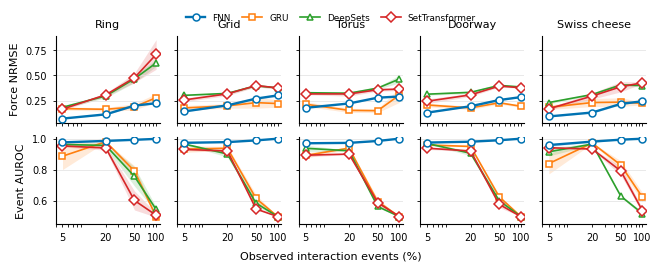

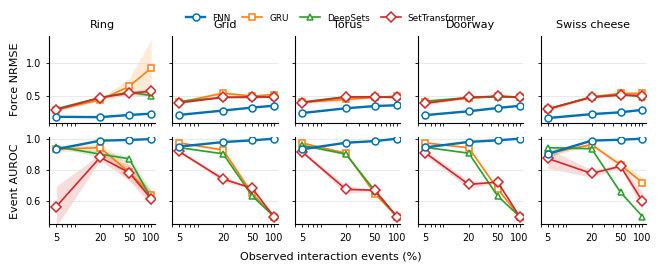

In [20]:
# ============================================================
# Observation-density ablation: 2 x 5
# Rows = NRMSE / AUROC
# Columns = topology
# One figure per dynamic
# ============================================================

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

OBSERVATION_FRACTIONS = {
    "very_sparse": 0.05,
    "sparse": 0.20,
    "medium": 0.50,
    "dense": 1.00,
}

REGIME_ORDER = [
    "very_sparse",
    "sparse",
    "medium",
    "dense",
]

MODEL_ORDER_ABLATION = [
    "fnn",
    "sum/tgn_gru",
    "deepsets/tgn_gru",
    "settransformer/tgn_gru",
]

TOPOLOGY_ORDER = [
    "ring",
    "grid",
    "torus",
    "doorway",
    "swisscheese",
]

TOPOLOGY_LABELS = {
    "ring": "Ring",
    "grid": "Grid",
    "torus": "Torus",
    "doorway": "Doorway",
    "swisscheese": "Swiss cheese",
}

METRICS = [
    ("rollout_test.rollout_force_nrmse", "Force NRMSE"),
    ("rollout_test.rollout_event_auroc", "Event AUROC"),
]


# ------------------------------------------------------------
# Final epoch only
# ------------------------------------------------------------

final_threshold_df = (
    threshold_df
    .loc[
        threshold_df["epoch"] == threshold_df["epochs"]
    ]
    .copy()
)

final_threshold_df["observed_fraction"] = (
    final_threshold_df["regime"]
    .map(OBSERVATION_FRACTIONS)
)


# ------------------------------------------------------------
# Aggregate across seeds
# ------------------------------------------------------------

def aggregate_threshold_metric(
    df,
    *,
    dynamic,
    topology,
    run,
    metric,
):
    work = (
        df.loc[
            (df["dynamic"] == dynamic)
            & (df["topology"] == topology)
            & (df["run"] == run),
            ["seed", "observed_fraction", metric]
        ]
        .dropna()
        .copy()
    )

    # One value per seed / observation fraction
    by_seed = (
        work
        .groupby(
            ["seed", "observed_fraction"],
            observed=True,
        )[metric]
        .mean()
        .reset_index()
    )

    summary = (
        by_seed
        .groupby(
            "observed_fraction",
            observed=True,
        )[metric]
        .agg(["mean", "std", "count"])
        .reset_index()
        .sort_values("observed_fraction")
    )

    summary["sem"] = (
        summary["std"].fillna(0)
        / np.sqrt(summary["count"])
    )

    summary["lower"] = summary["mean"] - summary["sem"]
    summary["upper"] = summary["mean"] + summary["sem"]

    return summary


# ------------------------------------------------------------
# Axis styling
# ------------------------------------------------------------

def style_threshold_axis(
    ax,
    *,
    title=None,
    ylabel=None,
    xlabel=None,
):
    if title is not None:
        ax.set_title(title)

    if ylabel is not None:
        ax.set_ylabel(ylabel)

    if xlabel is not None:
        ax.set_xlabel(xlabel)

    ax.set_xscale("log")
    ax.set_xlim(0.04, 1.12)

    ax.set_xticks([0.05, 0.20, 0.50, 1.00])
    ax.set_xticklabels(["5", "20", "50", "100"])

    ax.grid(
        axis="y",
        color="0.88",
        linewidth=0.5,
    )

    ax.grid(
        axis="x",
        visible=False,
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.tick_params(
        axis="both",
        length=2.5,
        width=0.6,
    )


# ------------------------------------------------------------
# Plot helper
# ------------------------------------------------------------

def plot_threshold_curve(
    ax,
    summary,
    run,
):
    color = MODEL_COLORS[run]

    x = summary["observed_fraction"].to_numpy()
    y = summary["mean"].to_numpy()
    lo = summary["lower"].to_numpy()
    hi = summary["upper"].to_numpy()

    ax.fill_between(
        x,
        lo,
        hi,
        color=color,
        alpha=0.16,
        linewidth=0,
        zorder=1,
    )

    line, = ax.plot(
        x,
        y,
        label=MODEL_LABELS[run],
        color=color,
        linewidth=MODEL_LINEWIDTHS[run],
        marker=MODEL_MARKERS[run],
        markersize=5.0,
        markerfacecolor="white",
        markeredgecolor=color,
        markeredgewidth=1.1,
        zorder=MODEL_ZORDERS[run],
    )

    return line


# ------------------------------------------------------------
# Main figure
# ------------------------------------------------------------

def plot_threshold_ablation_2x5(
    df,
    dynamic,
    *,
    save=True,
):
    fig, axes = plt.subplots(
        2,
        5,
        figsize=(6.5, 2.5),
        sharex=True,
        sharey="row",
        constrained_layout=True,
    )

    legend_handles = None

    for col, topology in enumerate(TOPOLOGY_ORDER):

        for row, (metric, ylabel) in enumerate(METRICS):

            ax = axes[row, col]

            handles = []

            for run in MODEL_ORDER_ABLATION:

                summary = aggregate_threshold_metric(
                    df,
                    dynamic=dynamic,
                    topology=topology,
                    run=run,
                    metric=metric,
                )

                if summary.empty:
                    continue

                line = plot_threshold_curve(
                    ax,
                    summary,
                    run,
                )

                handles.append(line)

            if legend_handles is None and handles:
                legend_handles = handles

            style_threshold_axis(
                ax,
                title=(
                    TOPOLOGY_LABELS[topology]
                    if row == 0
                    else None
                ),
                ylabel=(
                    ylabel
                    if col == 0
                    else None
                ),
                xlabel=None,
            )

            # AUROC bounds
            if metric.endswith("event_auroc"):
                ax.set_ylim(0.45, 1.01)

    # One shared x-axis label
    fig.supxlabel(
        "Observed interaction events (%)",
        fontsize=8,
    )

    # Shared legend
    if legend_handles:
        fig.legend(
            handles=legend_handles,
            labels=[
                MODEL_LABELS[run]
                for run in MODEL_ORDER_ABLATION
            ],
            loc="upper center",
            bbox_to_anchor=(0.5, 1.04),
            ncol=len(MODEL_ORDER_ABLATION),
            frameon=False,
            handlelength=2.2,
            columnspacing=1.3,
        )

    if save:
        out_dir = (
            REPO_ROOT
            / "derived"
            / "results"
            / "figures"
        )
        out_dir.mkdir(
            parents=True,
            exist_ok=True,
        )

        stem = f"threshold_ablation_{dynamic}_2x5"

        fig.savefig(
            out_dir / f"{stem}.pdf",
            bbox_inches="tight",
        )

        fig.savefig(
            out_dir / f"{stem}.png",
            bbox_inches="tight",
            dpi=600,
        )

    return fig, axes


# ------------------------------------------------------------
# Generate both dynamics
# ------------------------------------------------------------

fig_diffusion, axes_diffusion = plot_threshold_ablation_2x5(
    final_threshold_df,
    "diffusion",
)

plt.show()

fig_wave, axes_wave = plot_threshold_ablation_2x5(
    final_threshold_df,
    "wave",
)

plt.show()